# Load the POLECAT Conflict Networks

In [92]:
import scipy.sparse as sp

from dynrdpg.datasets import load_polecat

Y, node_names, time_labels = load_polecat(50)

# index of first week of 2024
k = -26

print('Average Density: ', round(Y.mean(), 3))

Average Density:  0.073


# Estimate the ASE

In [2]:
from sklearn.metrics import roc_auc_score, average_precision_score
from dynrdpg.dynrdpg import calculate_auc
from dynrdpg.dynrdpg import dynamic_adjacency_to_vec
from graspologic.embed import AdjacencySpectralEmbed as ASE

subdiag = np.tril_indices(Y[0].shape[0], k=-1)
y_vec = dynamic_adjacency_to_vec(Y[:k])
means = []
means_vec = []
dims = []
for t in range(len(Y[:k])):
    X_ase = ASE(n_components=None).fit_transform(sp.csr_array(Y[t]))
    dims.append(X_ase.shape[1])
    means.append(np.clip(X_ase @ X_ase.T, 0, 1))
    means_vec.append(means[t][subdiag])
means = np.stack(means)
means_vec = np.stack(means_vec)

print('AUC:', roc_auc_score(y_vec.ravel(), means_vec.ravel()))
print('AUPR:', average_precision_score(y_vec.ravel(), means_vec.ravel()))

/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


AUC: 0.7064535084664934
AUPR: 0.24843801519702985


# Histogram of $\hat{d}_{ASE}^{(t)}$ Estimates (Figure S.5)

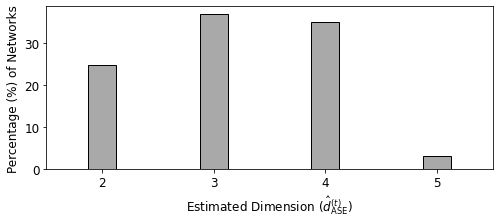

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.countplot(pd.DataFrame(dims, columns=['d']), 
              x='d', order=['2', '3', '4', '5'],
              stat='percent', color='darkgray', width=0.25,
              edgecolor='k',
              ax=ax)
ax.set_xlabel(r'Estimated Dimension ($\hat{d}_{\text{ASE}}^{(t)}$)', fontsize=12)
ax.set_ylabel('Percentage (%) of Networks', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)

# Sample GB-DASE [RW(2)]

In [66]:
from dynrdpg import DynamicRDPG

rdpg_rw2 = DynamicRDPG(n_features=4, rw_order=2, random_state=42)
rdpg_rw2.sample(Y[:k], n_burnin=5000, n_samples=5000)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [45:48<00:00,  3.64it/s]


In [73]:
print('AUC:', rdpg_rw2.auc_)
print('AUPR:', rdpg_rw2.aupr_)

AUC: 0.8611243700264195
AUPR: 0.4966893110975735


# Sample GB-DASE [RW(1)]

In [41]:
from dynrdpg import DynamicRDPG

rdpg_rw1 = DynamicRDPG(n_features=4, rw_order=1, random_state=13)
rdpg_rw1.sample(Y[:k], n_burnin=5000, n_samples=5000)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [43:36<00:00,  3.82it/s]


In [74]:
print('AUC:', rdpg_rw1.auc_)
print('AUPR:', rdpg_rw1.aupr_)

AUC: 0.8804155396772763
AUPR: 0.589541736213307


# Estimate OMNI

In [16]:
from sklearn.metrics import roc_auc_score, log_loss
from dynrdpg.dynrdpg import calculate_auc


from graspologic.embed import OmnibusEmbed as OMNI

omni = OMNI(n_components=None).fit(Y[:k])

means_omni = []
means_omni_vec = []
for t in range(len(Y[:k])):
    subdiag = np.tril_indices(Y[t].shape[0], k=-1)
    means_omni.append((omni.latent_left_[t] @ omni.latent_left_[t].T))
    means_omni_vec.append(means_omni[t][subdiag])

means_omni = np.clip(np.stack(means_omni), 0, 1)
means_omni_vec = np.clip(np.stack(means_omni_vec), 0, 1)

print('OMNI Dimension:', omni.n_components_)
print('AUC:', roc_auc_score(y_vec.ravel(), means_omni_vec.ravel()))
print('AUPR:', average_precision_score(y_vec.ravel(), means_omni_vec.ravel()))

OMNI Dimension: 5
AUC: 0.7678265759151994
AUPR: 0.3618803664974115


## Estimate MASE

In [18]:
from graspologic.embed import MultipleASE as MASE

mase = MASE().fit(Y[:k])
X_mase = mase.latent_left_
means_mase = []
means_mase_vec = []
for t in range(len(Y[:k])):
    subdiag = np.tril_indices(Y[t].shape[0], k=-1)
    R = mase.scores_[t]
    proba_mase = X_mase @ R @ X_mase.T
    means_mase.append(proba_mase)
    means_mase_vec.append(proba_mase[subdiag])

means_mase = np.clip(np.stack(means_mase), 0, 1)
means_mase_vec = np.clip(np.stack(means_mase_vec), 0, 1)

print('MASE Dimension:', X_mase.shape[1])
print('AUC:', roc_auc_score(y_vec.ravel(), means_mase_vec.ravel()))
print('AUPR:', average_precision_score(y_vec.ravel(), means_mase_vec.ravel()))

MASE Dimension: 3
AUC: 0.804018182293666
AUPR: 0.3843029689266141


## Estimate UASE

In [19]:
import scipy.sparse as sp
from graspologic.embed import select_dimension

n_nodes, _ = Y[0].shape
A = sp.csr_array(np.hstack([Yt for Yt in Y[:k]]))

d = select_dimension(A)[0][-1]

u, s, vh= sp.linalg.svds(A, k=d)
s_sqrt = np.sqrt(s)[::-1]
X_uase = (vh.T[:, ::-1] * s_sqrt).reshape(len(Y[:k]), n_nodes, d)
Y_uase = u[:, ::-1] * s_sqrt

means_uase = []
means_uase_vec = []
for t in range(X_uase.shape[0]):
    means_uase.append(np.clip(Y_uase @ X_uase[t].T, 0, 1))
    means_uase_vec.append(np.clip(Y_uase @ X_uase[t].T, 0, 1)[subdiag])
means_uase = np.clip(np.stack(means_uase), 0, 1)
means_uase_vec = np.clip(np.stack(means_uase_vec), 0, 1)


print('UASE Dimension:', X_uase.shape[2])
print('AUC:', roc_auc_score(y_vec.ravel(), means_uase_vec.ravel()))
print('AUPR:', average_precision_score(y_vec.ravel(), means_uase_vec.ravel()))

UASE Dimension: 3
AUC: 0.8155293346032778
AUPR: 0.39154356311098926


## Degree Distribution Goodness-of-Fit (Figure S.4) 

## Degree distributions from ASE-based competitors

In [48]:
from dynrdpg.dynamic_gof import degree

n_samples = 100
n_time_steps, n_nodes, _ = Y[:k].shape

deg_dist_ase = np.zeros((n_samples, n_time_steps, n_nodes))
rng = np.random.RandomState(123)
for idx in range(n_samples):
    y_sim = jnp.asarray(rng.binomial(n=1, p=means_vec))
    deg_dist_ase[idx] = degree(y_sim)
deg_dist_ase = deg_dist_ase.astype(int)

deg_dist_omni = np.zeros((n_samples, n_time_steps, n_nodes))
rng = np.random.RandomState(123)
for idx in range(n_samples):
    y_sim = jnp.asarray(rng.binomial(n=1, p=means_omni_vec))
    deg_dist_omni[idx] = degree(y_sim)
deg_dist_omni = deg_dist_omni.astype(int)

deg_dist_mase = np.zeros((n_samples, n_time_steps, n_nodes))
rng = np.random.RandomState(123)
for idx in range(n_samples):
    y_sim = jnp.asarray(rng.binomial(n=1, p=means_mase_vec))
    deg_dist_mase[idx] = degree(y_sim)
deg_dist_mase = deg_dist_mase.astype(int)

deg_dist_uase = np.zeros((n_samples, n_time_steps, n_nodes))
rng = np.random.RandomState(123)
for idx in range(n_samples):
    y_sim = jnp.asarray(rng.binomial(n=1, p=means_uase_vec))
    deg_dist_uase[idx] = degree(y_sim)
deg_dist_uase = deg_dist_uase.astype(int)

## Posterior Predictive from GB-DASE

In [75]:
deg_dist_rw2 = rdpg_rw2.posterior_predictive(degree, chunk_size=100)

deg_dist_rw1 = rdpg_rw1.posterior_predictive(degree, chunk_size=100)

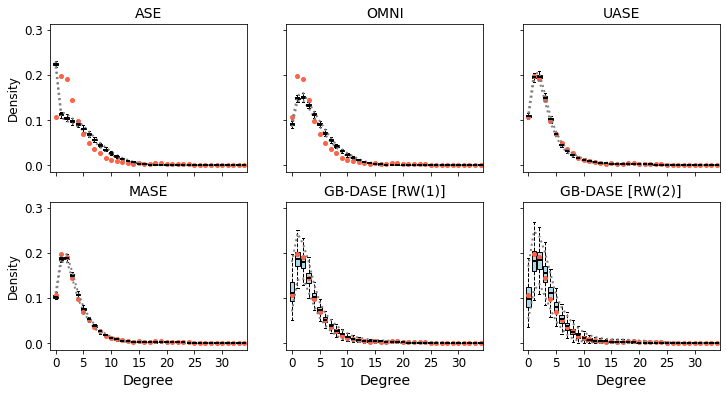

In [86]:
fig, ax = plt.subplots(figsize=(12, 6), ncols=3, nrows=2, sharey=True, sharex=True)
ax = ax.ravel()

BOXPLOT_PROPS = {
    'boxprops': {'facecolor':'#add8e6', 'edgecolor': 'black'},
    'medianprops': {'color': 'black', 'linewidth': 2},
    'whiskerprops': {'color': 'black', 'linestyle': '--'},
    'capprops': {'color': 'black'}
}

deg_dists = [deg_dist_ase, deg_dist_omni, 
             deg_dist_uase, deg_dist_mase,
            deg_dist_rw1, deg_dist_rw2]
names = ['ASE', 'OMNI', 'UASE', 'MASE', 'GB-DASE [RW(1)]', 'GB-DASE [RW(2)]']
for l, deg_dist in enumerate(deg_dists):
    
    n_samples, n_time_points, n_nodes = deg_dist.shape
    deg_pp = deg_dist.reshape(n_samples, n_time_points * n_nodes)

    obs_deg = Y.sum(axis=1)
    max_degree = int(obs_deg.max())
    min_plot, max_plot = 0, max_degree
    deg = np.zeros((deg_pp.shape[0], max_degree + 1))
    for i in range(deg_pp.shape[0]):
        deg[i] = np.bincount(deg_pp[i], minlength=max_degree+1)[:max_degree+1]
        deg[i] /= deg[i].sum()
    
    stat_dist = pd.melt(pd.DataFrame(deg), var_name='degree', value_name='count')

    obs_deg = np.bincount(obs_deg.ravel().astype(int), minlength=max_degree+1)[:max_degree+1]
    sns.boxplot(x='degree', y = 'count', 
            data=stat_dist, ax=ax[l], fliersize=0, **BOXPLOT_PROPS)
    ax[l].plot(obs_deg/obs_deg.sum(), 'o', color='tomato', 
               markersize=4, lw=3)


    bounds = stat_dist.groupby('degree').quantile([0.025, 0.975])
    ax[l].plot(bounds.xs(0.025, level=1).values.ravel(), ':', c='gray', lw=2)
    ax[l].plot(bounds.xs(0.975, level=1).values.ravel(), ':', c='gray', lw=2)
    if l > 3:
        ax[l].set_ylabel('Generalized Posterior\n Predictive Density', fontsize=12)
    else:
        ax[l].set_ylabel('Density', fontsize=12)
    ax[l].set_xlabel('Degree', fontsize=14)
    ax[l].set_xlim(min_plot-1, max_plot + 0.5)
    ax[l].set_xticks(np.arange(min_plot, max_plot+1)[::5])
    ax[l].set_title(names[l], fontsize=14)
    ax[l].tick_params(axis='both', which='major', labelsize=12)
    
fig.savefig('deg_predictive.pdf', bbox_inches='tight', dpi=300)

# Forecast Comparison (Table 2)

## GB-DASE [RW(2)] Forecasts

In [81]:
aupr = round(average_precision_score(Y[k][subdiag], rdpg_rw2.probas_[-1]), 4)
print(f"k = 0, AUPR: {aupr}")
    
probas_forecast = rdpg_rw2.forecast(k_steps=4, n_samples=1000, return_subdiag=True)
probas_forecast = probas_forecast.mean(axis=0)
for k_ahead in range(1, 5):
    y_true = Y[k+k_ahead][subdiag]
    forecast = probas_forecast[k_ahead-1]
    aupr = round(average_precision_score(y_true, forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.5789
k = 1, AUPR: 0.5214
k = 2, AUPR: 0.4877
k = 3, AUPR: 0.4969
k = 4, AUPR: 0.5543


## GB-DASE [RW(1)] Forecasts

In [78]:
aupr = round(average_precision_score(Y[k][subdiag], rdpg_rw1.probas_[-1]), 4)
print(f"k = 0, AUPR: {aupr}")
    
probas_forecast = rdpg_rw1.forecast(k_steps=4, n_samples=1000, return_subdiag=True)
probas_forecast = probas_forecast.mean(axis=0)
for k_ahead in range(1, 5):
    y_true = Y[k+k_ahead][subdiag]
    forecast = probas_forecast[k_ahead-1]
    aupr = round(average_precision_score(y_true, forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.5397
k = 1, AUPR: 0.4802
k = 2, AUPR: 0.4716
k = 3, AUPR: 0.4803
k = 4, AUPR: 0.509


## ASE Forecasts

In [82]:
proba_forecast = means_vec[-1]

for k_ahead in range(0, 5):
    y_true = Y[k+k_ahead][subdiag]
    aupr = round(average_precision_score(y_true, proba_forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.3379
k = 1, AUPR: 0.3413
k = 2, AUPR: 0.3626
k = 3, AUPR: 0.3007
k = 4, AUPR: 0.2856


## OMNI Forecasts

In [83]:
proba_forecast = means_omni_vec[-1]

for k_ahead in range(0, 5):
    y_true = Y[k+k_ahead][subdiag]
    aupr = round(average_precision_score(y_true, proba_forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.4451
k = 1, AUPR: 0.4041
k = 2, AUPR: 0.4366
k = 3, AUPR: 0.3909
k = 4, AUPR: 0.4258


## MASE Forecasts

In [84]:
proba_forecast = means_mase_vec[-1]

for k_ahead in range(0, 5):
    y_true = Y[k+k_ahead][subdiag]
    aupr = round(average_precision_score(y_true, proba_forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.389
k = 1, AUPR: 0.4179
k = 2, AUPR: 0.4361
k = 3, AUPR: 0.3226
k = 4, AUPR: 0.3812


## UASE Forecasts

In [85]:
proba_forecast = means_uase_vec[-1]

for k_ahead in range(0, 5):
    y_true = Y[k+k_ahead][subdiag]
    aupr = round(average_precision_score(y_true, proba_forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.3931
k = 1, AUPR: 0.3891
k = 2, AUPR: 0.4258
k = 3, AUPR: 0.307
k = 4, AUPR: 0.3546


# Israel-UN Conflict Probabilities [RW(2)] (Figure 4)

['Israel' 'United Nations']


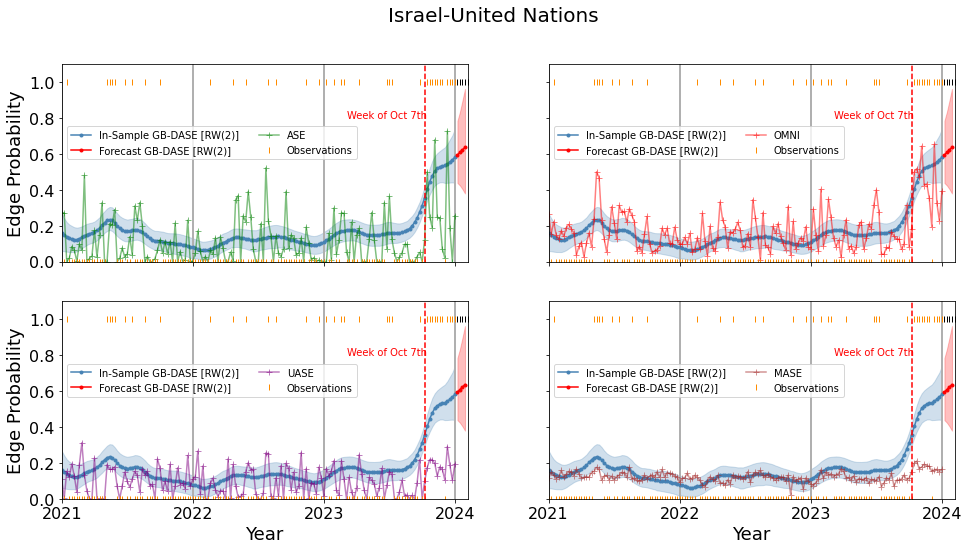

In [87]:
i, j = 2, 14
print(node_names[[i,j]])
k_steps = 4
Yd = Y[:k].copy()

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(16, 8), sharey=True, sharex=True)
ax = ax.ravel()

probas_pred = rdpg_rw2.predict(n_samples=2000)
probas_forecast = rdpg_rw2.forecast(k_steps=k_steps, n_samples=2500, return_subdiag=False)
for l, method in enumerate(['ASE', 'OMNI', 'UASE', 'MASE']):

    n_time_steps, n_nodes, _ = rdpg_rw2.X_.shape

    cis = np.quantile(probas_pred[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax[l].plot(np.arange(n_time_steps), cis[1], marker='.', color='steelblue', label='In-Sample GB-DASE [RW(2)]')
    ax[l].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

    k_steps = 4
    cis = np.quantile(probas_forecast[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax[l].plot(ts, cis[1], '-', marker='.', color='red', label = 'Forecast GB-DASE [RW(2)]')
    ax[l].fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
    ax[l].set_xlim(0, n_time_steps + k_steps)
    ax[l].set_ylim(0, 1.1)

    if method == 'ASE':
        ax[l].plot(means[:, i, j], '+-', color='green', alpha=0.5, label='ASE')
    elif method == 'OMNI':
        ax[l].plot(means_omni[:, i, j], '+-', color='red', alpha=0.5, label='OMNI')
    elif method == 'UASE':
        ax[l].plot(means_uase[:, i, j], '+-', color='purple', alpha=0.5, label='UASE')
    elif method == 'MASE':
        ax[l].plot(means_mase[:, i, j], '+-', color='brown', alpha=0.5, label='MASE')
 

    ax[l].plot(Yd[:, i, j], '|', color='darkorange', label='Observations')
    ax[l].plot(np.arange(len(Yd), len(Yd) - k), Y[k:, i, j], '|', color='black')

    ax[l].set_xticks([i * 52 for i in range(4)], labels=[2021 + i for i in range(4)], fontsize=20)
    ax[l].tick_params(axis='both', which='major', labelsize=16)
    ax[l].axvline(144, c='r', linestyle='--')
    ax[l].grid(axis='x', lw=2)
    ax[l].annotate('Week of Oct 7th', (113, 0.8), color='red')
    
    ax[l].legend(loc='center left', ncols=2, bbox_to_anchor=(0., 0.6))
    
    if l in [0, 2]:
        ax[l].set_ylabel('Edge Probability', fontsize=18)
        
    if l in [2, 3]:
        ax[l].set_xlabel('Year', fontsize=18)

        fig.suptitle(f"{node_names[i]}-{node_names[j]}", fontsize=20) 

fig.savefig('un_is_rw2.pdf', bbox_inches='tight', dpi=300)

# Palestine-US Conflict Probabilities [RW(2)] (Figure 5)

['Palestinian Territories' 'United States']


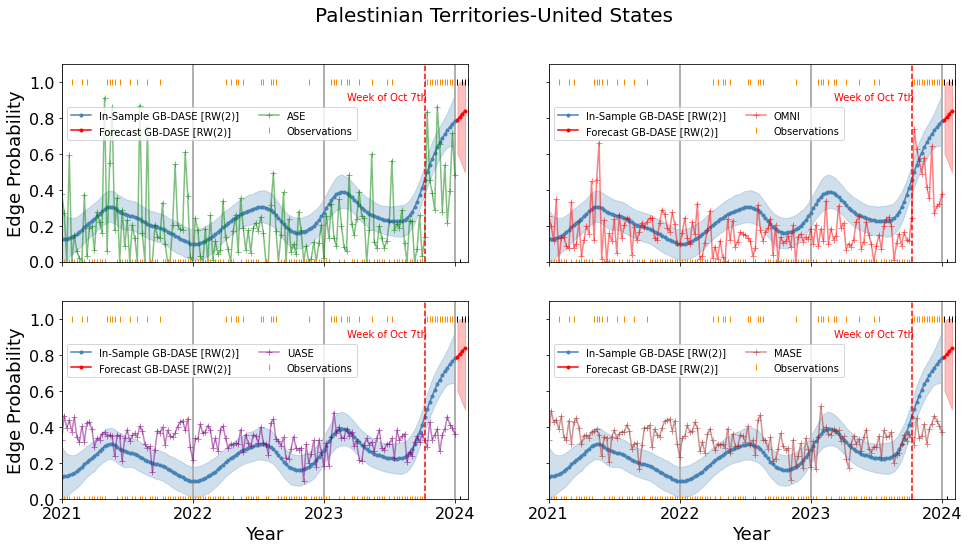

In [88]:
i, j = 20, 0
print(node_names[[i,j]])
Yd = Y[:k].copy()

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(16, 8), sharey=True, sharex=True)
ax = ax.ravel()

probas_pred = rdpg_rw2.predict(n_samples=2000)
probas_forecast = rdpg_rw2.forecast(k_steps=k_steps, n_samples=2500, return_subdiag=False)
for l, method in enumerate(['ASE', 'OMNI', 'UASE', 'MASE']):

    n_time_steps, n_nodes, _ = rdpg_rw2.X_.shape

    cis = np.quantile(probas_pred[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax[l].plot(np.arange(n_time_steps), cis[1], marker='.', color='steelblue', label='In-Sample GB-DASE [RW(2)]')
    ax[l].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

    k_steps = 4
    cis = np.quantile(probas_forecast[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax[l].plot(ts, cis[1], '-', marker='.', color='red', label = 'Forecast GB-DASE [RW(2)]')
    ax[l].fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
    ax[l].set_xlim(0, n_time_steps + k_steps)
    ax[l].set_ylim(0, 1.1)

    if method == 'ASE':
        ax[l].plot(means[:, i, j], '+-', color='green', alpha=0.5, label='ASE')
    elif method == 'OMNI':
        ax[l].plot(means_omni[:, i, j], '+-', color='red', alpha=0.5, label='OMNI')
    elif method == 'MASE':
        ax[l].plot(means_mase[:, i, j], '+-', color='brown', alpha=0.5, label='MASE')
    elif method == 'UASE':
        ax[l].plot(means_uase[:, i, j], '+-', color='purple', alpha=0.5, label='UASE')


    ax[l].plot(Yd[:, i, j], '|', color='darkorange', label='Observations')
    ax[l].plot(np.arange(len(Yd), len(Yd) - k), Y[k:, i, j], '|', color='black')

    ax[l].set_xticks([i * 52 for i in range(4)], labels=[2021 + i for i in range(4)], fontsize=20)
    ax[l].tick_params(axis='both', which='major', labelsize=16)
    ax[l].axvline(144, c='r', linestyle='--')
    ax[l].grid(axis='x', lw=2)
    ax[l].annotate('Week of Oct 7th', (113, 0.9), color='red')
    
    ax[l].legend(loc='center left', ncols=2, bbox_to_anchor=(0., 0.7))

    
    if l in [0, 2]:
        ax[l].set_ylabel('Edge Probability', fontsize=18)
        
    if l in [2, 3]:
        ax[l].set_xlabel('Year', fontsize=18)

        fig.suptitle(f"{node_names[i]}-{node_names[j]}", fontsize=20) 
        
fig.savefig('pl_us_rw2.pdf', bbox_inches='tight', dpi=300)

# Israel-UN Conflict Probabilities [RW(1)] (Figure S.6)

['Israel' 'United Nations']


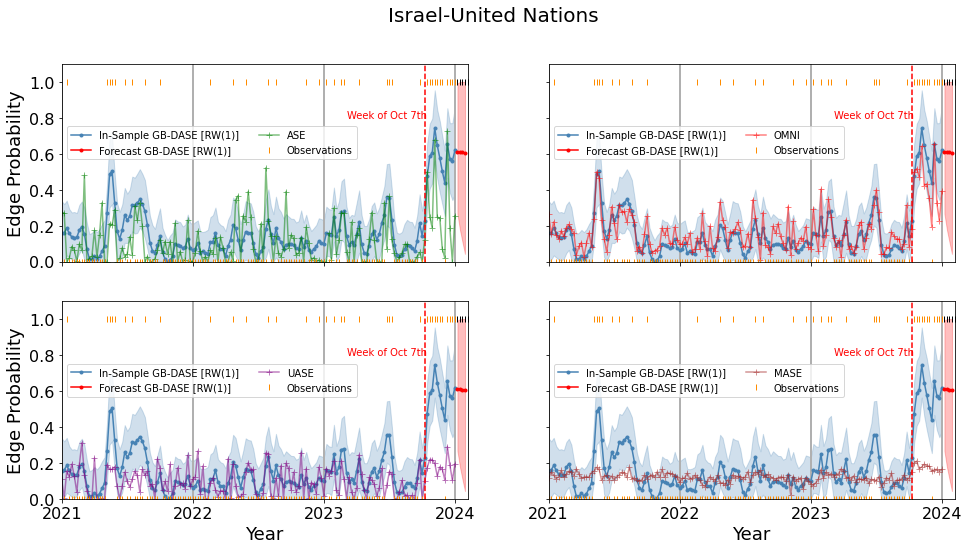

In [89]:
i, j = 2, 14
print(node_names[[i,j]])
Yd = Y[:k].copy()

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(16, 8), sharey=True, sharex=True)
ax = ax.ravel()

probas_pred = rdpg_rw1.predict(n_samples=2000)
probas_forecast = rdpg_rw1.forecast(k_steps=k_steps, n_samples=2500, return_subdiag=False)
for l, method in enumerate(['ASE', 'OMNI', 'UASE', 'MASE']):

    n_time_steps, n_nodes, _ = rdpg_rw1.X_.shape

    cis = np.quantile(probas_pred[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax[l].plot(np.arange(n_time_steps), cis[1], marker='.', color='steelblue', label='In-Sample GB-DASE [RW(1)]')
    ax[l].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

    k_steps = 4
    cis = np.quantile(probas_forecast[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax[l].plot(ts, cis[1], '-', marker='.', color='red', label = 'Forecast GB-DASE [RW(1)]')
    ax[l].fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
    ax[l].set_xlim(0, n_time_steps + k_steps)
    ax[l].set_ylim(0, 1.1)

    if method == 'ASE':
        ax[l].plot(means[:, i, j], '+-', color='green', alpha=0.5, label='ASE')
    elif method == 'OMNI':
        ax[l].plot(means_omni[:, i, j], '+-', color='red', alpha=0.5, label='OMNI')
    elif method == 'UASE':
        ax[l].plot(means_uase[:, i, j], '+-', color='purple', alpha=0.5, label='UASE')

    elif method == 'MASE':
        ax[l].plot(means_mase[:, i, j], '+-', color='brown', alpha=0.5, label='MASE')


    ax[l].plot(Yd[:, i, j], '|', color='darkorange', label='Observations')
    ax[l].plot(np.arange(len(Yd), len(Yd) - k), Y[k:, i, j], '|', color='black')

    ax[l].set_xticks([i * 52 for i in range(4)], labels=[2021 + i for i in range(4)], fontsize=20)
    ax[l].tick_params(axis='both', which='major', labelsize=16)
    ax[l].axvline(144, c='r', linestyle='--')
    ax[l].grid(axis='x', lw=2)
    ax[l].annotate('Week of Oct 7th', (113, 0.8), color='red')
    ax[l].legend(loc='center left', ncols=2, bbox_to_anchor=(0., 0.6))
    
    #if l in [0, 1]:

    
    if l in [0, 2]:
        ax[l].set_ylabel('Edge Probability', fontsize=18)
        
    if l in [2, 3]:
        ax[l].set_xlabel('Year', fontsize=18)

        fig.suptitle(f"{node_names[i]}-{node_names[j]}", fontsize=20) 

fig.savefig('un_is_rw1.pdf', bbox_inches='tight', dpi=300)

# Palestine-US Conflict Probabilities [RW(1)] (Figure S.7)

['Palestinian Territories' 'United States']


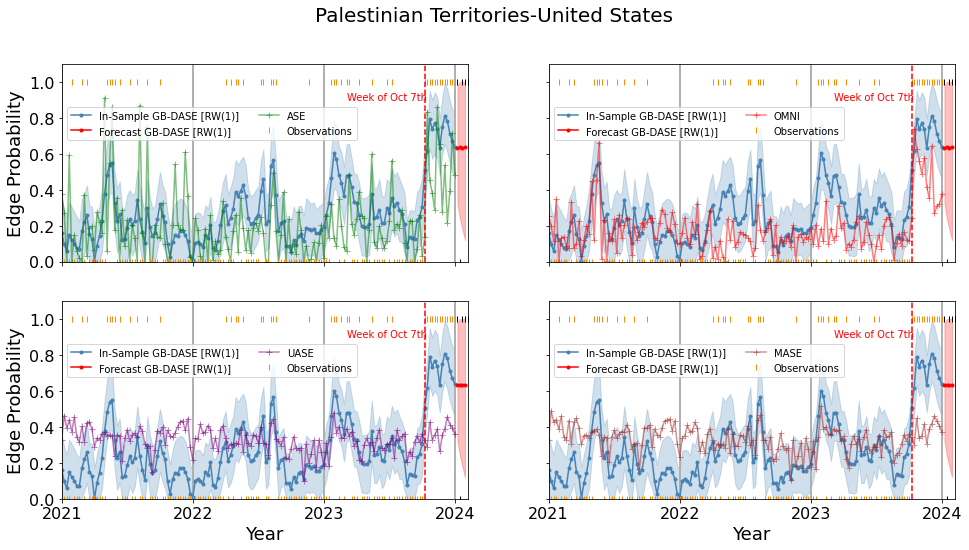

In [90]:
i, j = 20, 0
print(node_names[[i,j]])
Yd = Y[:k].copy()

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(16, 8), sharey=True, sharex=True)
ax = ax.ravel()

probas_pred = rdpg_rw1.predict(n_samples=2000)
probas_forecast = rdpg_rw1.forecast(k_steps=k_steps, n_samples=2500, return_subdiag=False)
for l, method in enumerate(['ASE', 'OMNI', 'UASE', 'MASE']):

    n_time_steps, n_nodes, _ = rdpg_rw1.X_.shape

    cis = np.quantile(probas_pred[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax[l].plot(np.arange(n_time_steps), cis[1], marker='.', color='steelblue', label='In-Sample GB-DASE [RW(1)]')
    ax[l].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

    k_steps = 4
    cis = np.quantile(probas_forecast[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax[l].plot(ts, cis[1], '-', marker='.', color='red', label = 'Forecast GB-DASE [RW(1)]')
    ax[l].fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
    ax[l].set_xlim(0, n_time_steps + k_steps)
    ax[l].set_ylim(0, 1.1)

    if method == 'ASE':
        ax[l].plot(means[:, i, j], '+-', color='green', alpha=0.5, label='ASE')
    elif method == 'OMNI':
        ax[l].plot(means_omni[:, i, j], '+-', color='red', alpha=0.5, label='OMNI')
    elif method == 'MASE':
        ax[l].plot(means_mase[:, i, j], '+-', color='brown', alpha=0.5, label='MASE')
    elif method == 'UASE':
        ax[l].plot(means_uase[:, i, j], '+-', color='purple', alpha=0.5, label='UASE')


    ax[l].plot(Yd[:, i, j], '|', color='darkorange', label='Observations')
    ax[l].plot(np.arange(len(Yd), len(Yd) - k), Y[k:, i, j], '|', color='black')

    ax[l].set_xticks([i * 52 for i in range(4)], labels=[2021 + i for i in range(4)], fontsize=20)
    ax[l].tick_params(axis='both', which='major', labelsize=16)
    ax[l].axvline(144, c='r', linestyle='--')
    ax[l].grid(axis='x', lw=2)
    ax[l].annotate('Week of Oct 7th', (113, 0.9), color='red')
    ax[l].legend(loc='center left', ncols=2, bbox_to_anchor=(0., 0.7))
    
    #if l in [0, 1]:

    
    if l in [0, 2]:
        ax[l].set_ylabel('Edge Probability', fontsize=18)
        
    if l in [2, 3]:
        ax[l].set_xlabel('Year', fontsize=18)

        fig.suptitle(f"{node_names[i]}-{node_names[j]}", fontsize=20) 

fig.savefig('pl_us_rw1.pdf', bbox_inches='tight', dpi=300)